# Hotspot Sequence Similarity Checks

This notebook checks for exact duplicates and near-duplicate siRNAs inside the worst narrow regimes.
The goal is to identify a real removal signal: nearly identical sequence pairs with strongly conflicting inhibition labels.

## Why This Matters

- A hotspot can look difficult because it is biologically hard.
- It can also look difficult because near-identical siRNAs have inconsistent labels.
- If we find many exact or near-exact sequence matches with very different inhibition values, that is a much stronger argument for data cleaning or removal than just poor model performance alone.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from xgboost import XGBRegressor

project_root = Path.cwd().resolve()
while not (project_root / "utils").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if not (project_root / "utils").exists():
    raise RuntimeError("Could not locate project root containing the utils package")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.merge_historic_data import load_merged_dataset
from utils.pipeline import SiRNADataPipeline
from utils.splitter import GroupKFoldLeakPerGroup

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## Step 1: Rebuild The Held-Out Prediction Frame

Why: the narrow regimes should be defined on the same cleaned dataset and prediction frame used in the other investigation notebooks.

In [2]:
cmsirna_path = os.environ.get("CMSIRNA_RAW_DATA_PATH")
historic_path = os.environ.get("CMSIRNA_RAW_HISTORIC_DATA_PATH")

assert cmsirna_path, "CMSIRNA_RAW_DATA_PATH is not set"
assert historic_path, "CMSIRNA_RAW_HISTORIC_DATA_PATH is not set"

raw_df = load_merged_dataset(cmsirna_path, historic_path)
pipeline = SiRNADataPipeline(target_len=25, fetch_missing_mrna=True)
enriched_df = pipeline.enrich_dataset_with_encodings(
    raw_df,
    strict_cleaning=True,
    add_mrna=True,
)
X, groups, y = pipeline.prepare_for_classical_ml(
    enriched_df,
    target_column="Inhibition",
    use_normalized_conditions=False,
)

mask = ~np.isnan(y)
X = X[mask]
groups = groups[mask]
y = y[mask]
analysis_df = enriched_df.loc[mask].reset_index(drop=True).copy()

analysis_df["patent_group"] = analysis_df.get(
    "patent_ID", pd.Series(index=analysis_df.index, dtype=object)
).fillna("HISTORIC_OR_UNKNOWN")
analysis_df["Authorization_status"] = analysis_df.get(
    "Authorization_status", pd.Series(index=analysis_df.index, dtype=object)
).fillna("UNKNOWN")

analysis_df.shape

loaded 3515 historic rows
merged 43153 CMsiRNA and 3515 historic rows into 46668
Running qc and data cleaning
dropped 4233 rows for in-vivo readings
dropped 565 rows for mM readings
dropped 115 rows for unknown or unwanted cell lines
dropped 47 rows for out-of-range inhibition
dropped 1749 rows for missing or unknown concentration
dropped 796 rows for concentration > 200 nM
filled 7522 rows for missing time of administration
dropped 2198 rows with a missing or >25 nt strand
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Mapping mRNA structural profiles
Error reading reference dataset: [Errno 2] No such file or directory: '/home/larsena8/software/fennec/src/fennec/support_files/train_data_v1.1.0_N=27742.csv'
Loaded 47 gene sequences from local cache
Loaded 0 gene sequences from reference CSV
Building gene -> mRNA

(35444, 40)

In [3]:
frozen_params = {
    "n_estimators": 800,
    "max_depth": 4,
    "learning_rate": 0.15881823130907038,
    "subsample": 0.8812898741586134,
    "colsample_bytree": 0.7824379872752019,
    "min_child_weight": 4,
    "reg_lambda": 0.8342807691178866,
    "reg_alpha": 1.4296995092035882,
    "gamma": 0.07531958697602548,
}

gene_cv = GroupKFoldLeakPerGroup(n_splits=3, leak_n=0, random_state=42)
oof_frames = []

for fold_id, (train_idx, test_idx) in enumerate(gene_cv.split(X, y, groups), start=1):
    model = XGBRegressor(tree_method="hist", n_jobs=-1, random_state=42, **frozen_params)
    model.fit(X[train_idx], y[train_idx])
    fold_pred = model.predict(X[test_idx])

    fold_frame = analysis_df.iloc[test_idx].reset_index().rename(columns={"index": "source_index"}).copy()
    fold_frame["row_index"] = test_idx
    fold_frame["fold_id"] = fold_id
    fold_frame["group"] = groups[test_idx]
    fold_frame["y_true"] = y[test_idx]
    fold_frame["y_pred"] = fold_pred
    fold_frame["residual"] = fold_frame["y_true"] - fold_frame["y_pred"]
    fold_frame["abs_error"] = fold_frame["residual"].abs()
    fold_frame["prediction_bias"] = fold_frame["y_pred"] - fold_frame["y_true"]
    oof_frames.append(fold_frame)

predictions_df = pd.concat(oof_frames, ignore_index=True)
predictions_df.head()

,source_index,ID,patent_ID,Authorization_status,Accession_number,gene_target_symbol_name,Gene_ID,The_name_of_double_helix,Antisense_seqence,length_anti_sense_strand,Modifications_AntiSense_strand,Modification_Types_Antisense_strand,Sense_seqence,length_sense_strand,Modification_Types_Sense_strand,Inhibition,SD,Cell_Type,Concentration,Time_of_administration,Title,mRNA,Concentration_nM,Time_of_administration_h,mRNA_five_prime,mRNA_three_prime,edit_distance,target_site_pct,Sense_Sequence_One_Hot,Antisense_Sequence_One_Hot,Sense_Acid_One_Hot,Sense_Sugar_One_Hot,Sense_Linker_One_Hot,Antisense_Acid_One_Hot,Antisense_Sugar_One_Hot,Antisense_Linker_One_Hot,Cell_Type_One_Hot,Concentration_log10_nM,Concentration_norm,Time_norm,patent_group,row_index,fold_id,group,y_true,y_pred,residual,abs_error,prediction_bias
0,4680,004-03-02-01275-1n-XXX--1.20,CN108368506A,Substantive Examination,NM_005577.4,LPA,4018.0,AD00571,TCGGCAGUCCCUUCUGCGUTT,21.0,dTCfgGfcAfgUfcCfcUfuCfuGfcGfudTsdT,1*2'-Deoxy thymidine || 2*2'-Fluorocytidine ||...,ACGCAGAAGGGACUGCCGAT,20.0,1*2'-Fluoroadenosine || 2*2'-O-Methylcytidine ...,-1.2,14.6,Hep3B,1.0,24.0,用于抑制LPA的基因表达的组合物和方法,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,1.0,24.0,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,UUGGACGGGAGACAGAGUGAAGCAUCAACCUACUUAGAAGCUGAAA...,2.0,0.058778,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0....","[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0], [0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",0.0,0.620954,0.121951,CN108368506A,4680,1,LPA,-1.2,34.769035,-35.969035,35.969035,35.969035
1,4681,004-03-02-01276-1n-XXX-22.40,CN108368506A,Substantive Examination,NM_005577.4,LPA,4018.0,AD00572,TGUAGCACUCCUGCACCCCTT,21.0,dTGfuAfgCfaCfuCfcUfgCfaCfcCfcdTsdT,1*2'-Deoxy thymidine || 2*2'-Fluoroguanosine |...,GGGGUGCAGGAGUGCUACAT,20.0,1*2'-Fluoroguanosine || 2*2'-O-Methylguanosine...,22.4,6.2,Hep3B,1.0,24.0,用于抑制LPA的基因表达的组合物和方法,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,1.0,24.0,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,UUGGACGGGAGACAGAGUGAAGCAUCAACCUACUUAGAAGCUGAAA...,3.0,0.073084,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0....","[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0], [0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",0.0,0.620954,0.121951,CN108368506A,4681,1,LPA,22.4,0.201030,22.198970,22.198970,-22.198970
2,4682,004-03-02-01277-1n-XXX-29.20,CN108368506A,Substantive Examination,NM_005577.4,LPA,4018.0,AD00573,TAAUAAGGGGCUGCCACAGTT,21.0,dTAfaUfaAfgGfgGfcUfgCfcAfcAfgdTsdT,1*2'-Deoxy thymidine || 2*2'-Fluoroadenosine |...,CUGUGGCAGCCCCUUAUUAT,20.0,1*2'-Fluorocytidine || 2*2'-O-Methyluridine ||...,29.2,5.4,Hep3B,1.0,24.0,用于抑制LPA的基因表达的组合物和方法,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,1.0,24.0,GUAAGUCAACAAUGUCCUGGGAUUGGGACACACUUUCUGGGCACUG...,UUGGACGGGAGACAGAGUGAAGCAUCAACCUACUUAGAAGCUGAAA...,3.0,0.419219,"[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0], [0.0, 1....","[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0], [1.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",0.0,0.620954,0.121951,CN108368506A,4682,1,LPA,29.2,47.724365,-18.524365,18.

## Step 2: Define The Narrow Regimes To Audit

Why: we only want to run duplicate and similarity checks inside the exact hotspots that already looked suspicious in the earlier notebooks.

In [4]:
predictions_df["regime_label"] = np.select(
    [
        predictions_df["group"].eq("AGT") & predictions_df["Cell_Type"].eq("Hep3B") & predictions_df["Concentration_nM"].isin([0.1, 10.0]),
        predictions_df["group"].eq("APP") & np.isclose(predictions_df["Concentration_nM"], 20.0, equal_nan=False) & predictions_df["Cell_Type"].eq("Hela"),
        predictions_df["group"].eq("INHBE") & np.isclose(predictions_df["Concentration_nM"], 100.0, equal_nan=False),
        predictions_df["group"].eq("MAPT") & predictions_df["Concentration_nM"].isin([40.0, 200.0]),
        predictions_df["group"].eq("PLN") & np.isclose(predictions_df["Concentration_nM"], 10.0, equal_nan=False) & predictions_df["Cell_Type"].eq("Hepa1-6"),
    ],
    [
        "AGT + Hep3B + {0.1,10} nM",
        "APP + Hela + 20 nM",
        "INHBE + 100 nM",
        "MAPT + {40,200} nM",
        "PLN + Hepa1-6 + 10 nM",
    ],
    default="Other",
)

predictions_df["regime_label"].value_counts()

regime_label
Other                        32278
AGT + Hep3B + {0.1,10} nM     2522
INHBE + 100 nM                 180
APP + Hela + 20 nM             170
MAPT + {40,200} nM             159
PLN + Hepa1-6 + 10 nM          135
Name: count, dtype: int64

## Step 3: Normalize Sequence Strings

Why: exact duplicate checks only work if sequence formatting differences like whitespace or case are removed first.

In [5]:
def normalize_seq(value):
    if pd.isna(value):
        return None
    return "".join(str(value).upper().split())

predictions_df["sense_seq_norm"] = predictions_df["Sense_seqence"].map(normalize_seq)
predictions_df["antisense_seq_norm"] = predictions_df["Antisense_seqence"].map(normalize_seq)
predictions_df["duplex_key"] = (
    predictions_df["sense_seq_norm"].fillna("MISSING")
    + "||"
    + predictions_df["antisense_seq_norm"].fillna("MISSING")
)

predictions_df[["sense_seq_norm", "antisense_seq_norm", "duplex_key"]].head()

,sense_seq_norm,antisense_seq_norm,duplex_key
0,ACGCAGAAGGGACUGCCGAT,TCGGCAGUCCCUUCUGCGUTT,ACGCAGAAGGGACUGCCGAT||TCGGCAGUCCCUUCUGCGUTT
1,GGGGUGCAGGAGUGCUACAT,TGUAGCACUCCUGCACCCCTT,GGGGUGCAGGAGUGCUACAT||TGUAGCACUCCUGCACCCCTT
2,CUGUGGCAGCCCCUUAUUAT,TAAUAAGGGGCUGCCACAGTT,CUGUGGCAGCCCCUUAUUAT||TAAUAAGGGGCUGCCACAGTT
3,GGCAGCCCCUUAUUGUUAAT,TUAACAAUAAGGGGCUGCCTT,GGCAGCCCCUUAUUGUUAAT||TUAACAAUAAGGGGCUGCCTT
4,AGCCCCUUAUUGUUAUACAT,TGUAUAACAAUAAGGGGCUTT,AGCCCCUUAUUGUUAUACAT||TGUAUAACAAUAAGGGGCUTT


## Step 4: Exact Duplicate Checks

Why: if the same duplex appears multiple times in the same narrow regime with very different inhibition labels, that is the clearest signal of inconsistency.

In [6]:
duplicate_rows = []
for regime, regime_df in predictions_df.loc[predictions_df["regime_label"] != "Other"].groupby("regime_label"):
    grouped = regime_df.groupby("duplex_key")
    for duplex_key, dup_df in grouped:
        if len(dup_df) < 2:
            continue
        duplicate_rows.append({
            "regime_label": regime,
            "duplex_key": duplex_key,
            "n_rows": len(dup_df),
            "y_true_min": float(dup_df["y_true"].min()),
            "y_true_max": float(dup_df["y_true"].max()),
            "y_true_range": float(dup_df["y_true"].max() - dup_df["y_true"].min()),
            "mean_abs_error": float(dup_df["abs_error"].mean()),
            "patents": sorted(dup_df["patent_group"].astype(str).unique().tolist()),
            "cell_types": sorted(dup_df["Cell_Type"].astype(str).unique().tolist()),
            "concentrations": sorted(dup_df["Concentration_nM"].astype(float).unique().tolist()),
            "times": sorted(dup_df["Time_of_administration_h"].astype(float).unique().tolist()),
        })

exact_duplicate_summary = pd.DataFrame(duplicate_rows).sort_values(["y_true_range", "n_rows"], ascending=[False, False]) if duplicate_rows else pd.DataFrame()
exact_duplicate_summary.head(30)

,regime_label,duplex_key,n_rows,y_true_min,y_true_max,y_true_range,mean_abs_error,patents,cell_types,concentrations,times
605,"AGT + Hep3B + {0.1,10} nM",GUCUCACUUUCCAGCAAAA||UUUUGCUGGAAAGUGAGACCC,4,-99.50,88.20,187.70,73.002868,[CN117448322A],[Hep3B],[0.1],[24.0]
604,"AGT + Hep3B + {0.1,10} nM",GUCUCACUUUCCAGCAAAAUU||UUUUGCUGGAAAGUGAGACCC,6,-86.20,90.50,176.70,65.383700,[CN117448322A],[Hep3B],[0.1],[24.0]
402,"AGT + Hep3B + {0.1,10} nM",CUGGCCAACUUCUUGGGCUUU||AAAGCCCAAGAAGUUGGCCAGCA,4,-22.00,92.00,114.00,42.914861,[WO2023014765A1],[Hep3B],"[0.1, 10.0]",[24.0]
63,"AGT + Hep3B + {0.1,10} nM",ACAGGUUCAUGCAGGCUGUGU||ACACAGCCUGCAUGAACCUGUCA,4,-40.00,73.00,113.00,34.193757,[WO2023014765A1],[Hep3B],"[0.1, 10.0]",[24.0]
369,"AGT + Hep3B + {0.1,10} nM",CGUUUCUCCUUGGUCUAAGUU||CACUUAGACCAAGGAGAAACGUC,4,-20.70,91.00,111.70,59.160801,[CN117448322A],[Hep3B],[0.1],[24.0]
581,"AGT + Hep3B + {0.1,10} nM",GGUGGAGGGUCUCACUUUCCU||AGGAAAGUGAGACCCUCCACCUU,4,-18.00,90.00,108.00,31.302096,[WO2023014765A1],[Hep3B],"[0.1, 10.0]",[24.0]
994,"MAPT + {40,200} nM",AUAGUCUACAAACCAGUUGAA||UUCAACUGGUUUGUAGACUAU,68,-7.70,96.10,103.80,31.754142,[WO2023175091A2],[Human iPSC-derived cortical neurons],"[40.0, 200.0]",[168.0]
160,"AGT + Hep3B + {0.1,10} nM",AUACACCCCUUCCACCUCGUU||AACGAGGUGGAAGGGGUGUAUGU,4,-31.00,70.00,101.00,22.475256,[WO2023014765A1],[Hep3B],"[0.1, 10.0]",[24.0]
571,"AGT + Hep3B + {0.1,10} nM",GGGUGUACAUACACCCCUUCU||AGAAGGGGUGUAUGUACACCCGG,4,-16.00,82.00,98.00,30.107914,[WO2023014765A1],[Hep3B],"[0.1, 10.0]",[24.0]
789,"AGT + Hep3B + {0.1,10} nM",UGGUCGGGAUGCUGGCCAACU||AGUUGGCCAGCAUCCCGACCAUU,4,-2.00,95.00,97.00,40.015462,[WO2023014765A1],[Hep3B],"[0.1, 10.0]",[24.0]


## Step 5: Near-Duplicate Checks

Why: some siRNAs differ by only one or two positions. If those nearly identical duplexes have sharply conflicting labels inside the same regime, that is also suspicious.

In [7]:
def hamming_or_none(left, right):
    if left is None or right is None:
        return None
    if len(left) != len(right):
        return None
    return sum(a != b for a, b in zip(left, right))

def pairwise_near_duplicates(regime_df, max_distance=2, min_label_gap=20.0):
    rows = []
    subset = regime_df.reset_index(drop=True)
    for i, j in combinations(range(len(subset)), 2):
        left = subset.iloc[i]
        right = subset.iloc[j]
        sense_dist = hamming_or_none(left["sense_seq_norm"], right["sense_seq_norm"])
        antisense_dist = hamming_or_none(left["antisense_seq_norm"], right["antisense_seq_norm"])
        if sense_dist is None or antisense_dist is None:
            continue
        total_dist = sense_dist + antisense_dist
        label_gap = abs(float(left["y_true"]) - float(right["y_true"]))
        if total_dist <= max_distance and label_gap >= min_label_gap:
            rows.append({
                "left_id": left.get("ID"),
                "right_id": right.get("ID"),
                "group": left["group"],
                "cell_type": left["Cell_Type"],
                "concentration_left": float(left["Concentration_nM"]),
                "concentration_right": float(right["Concentration_nM"]),
                "time_left": float(left["Time_of_administration_h"]),
                "time_right": float(right["Time_of_administration_h"]),
                "sense_hamming": sense_dist,
                "antisense_hamming": antisense_dist,
                "total_hamming": total_dist,
                "y_true_left": float(left["y_true"]),
                "y_true_right": float(right["y_true"]),
                "label_gap": label_gap,
                "patent_left": left["patent_group"],
                "patent_right": right["patent_group"],
            })
    return pd.DataFrame(rows)


In [8]:
near_duplicate_frames = []
for regime, regime_df in predictions_df.loc[predictions_df["regime_label"] != "Other"].groupby("regime_label"):
    pairs_df = pairwise_near_duplicates(regime_df, max_distance=2, min_label_gap=20.0)
    if pairs_df.empty:
        continue
    pairs_df.insert(0, "regime_label", regime)
    near_duplicate_frames.append(pairs_df)

near_duplicate_summary = pd.concat(near_duplicate_frames, ignore_index=True) if near_duplicate_frames else pd.DataFrame()
near_duplicate_summary.sort_values(["label_gap", "total_hamming"], ascending=[False, True]).head(50)

,regime_label,left_id,right_id,group,cell_type,concentration_left,concentration_right,time_left,time_right,sense_hamming,antisense_hamming,total_hamming,y_true_left,y_true_right,label_gap,patent_left,patent_right
1709,"AGT + Hep3B + {0.1,10} nM",078-12-02-13790-0.1n-24h-88.20,078-12-02-13803-0.1n-24h--99.50,AGT,Hep3B,0.1,0.1,24.0,24.0,0,0,0,88.2,-99.5,187.7,CN117448322A,CN117448322A
1726,"AGT + Hep3B + {0.1,10} nM",078-12-02-13790-0.1n-24h-87.70,078-12-02-13803-0.1n-24h--99.50,AGT,Hep3B,0.1,0.1,24.0,24.0,0,0,0,87.7,-99.5,187.2,CN117448322A,CN117448322A
1710,"AGT + Hep3B + {0.1,10} nM",078-12-02-13791-0.1n-24h-79.30,078-12-02-13803-0.1n-24h--99.50,AGT,Hep3B,0.1,0.1,24.0,24.0,0,0,0,79.3,-99.5,178.8,CN117448322A,CN117448322A
1699,"AGT + Hep3B + {0.1,10} nM",078-12-02-13787-0.1n-24h-90.50,078-12-02-13794-0.1n-24h--86.20,AGT,Hep3B,0.1,0.1,24.0,24.0,0,0,0,90.5,-86.2,176.7,CN117448322A,CN117448322A
1708,"AGT + Hep3B + {0.1,10} nM",078-12-02-13789-0.1n-24h-87.80,078-12-02-13794-0.1n-24h--86.20,AGT,Hep3B,0.1,0.1,24.0,24.0,0,0,0,87.8,-86.2,174.0,CN117448322A,CN117448322A
1729,"AGT + Hep3B + {0.1,10} nM",078-12-02-13794-0.1n-24h-75.60,078-12-02-13794-0.1n-24h--86.20,AGT,Hep3B,0.1,0.1,24.0,24.0,0,0,0,75.6,-86.2,161.8,CN117448322A,CN117448322A
1719,"AGT + Hep3B + {0.1,10} nM",078-12-02-13787-0.1n-24h-73.70,078-12-02-13794-0.1n-24h--86.20,AGT,Hep3B,0.1,0.1,24.0,24.0,0,0,0,73.7,-86.2,159.9,CN117448322A,CN117448322A
253,"AGT + Hep3B + {0.1,10} nM",065-12-02-12151-10n-XXX-92.00,065-12-02-12115-0.1n-XXX--22.00,AGT,Hep3B,10.0,0.1,24.0,24.0,0,0,0,92.0,-22.0,114.0,WO2023014765A1,WO2023014765A1
1688,"AGT + Hep3B + {0.1,10} nM",078-12-02-13785-0.1n-24h-91.00,078-12-02-13804-0.1n-24h--22.90,AGT,Hep3B,0.1,0.1,24.0,24.0,1,0,1,91.0,-22.9,113.9,CN117448322A,CN117448322A
378,"AGT + Hep3B + {0.1,10} nM",065-12-02-12243-10n-XXX-73.00,065-12-02-12205-0.1n-XXX--40.00,AGT,Hep3B,10.0,0.1,24.0,24.0,0,0,0,73.0,-40.0,113.0,WO2023014765A1,WO2023014765A1


## Step 6: Regime-Level Inconsistency Summary

Why: we want a compact view of which narrow regimes have the strongest exact-duplicate disagreement or near-duplicate conflict.

In [9]:
regime_counts = predictions_df.loc[predictions_df["regime_label"] != "Other", "regime_label"].value_counts().rename("n_rows")

exact_stats = pd.DataFrame(columns=["regime_label", "n_duplicate_groups", "max_exact_label_range", "mean_exact_label_range"])
if not exact_duplicate_summary.empty:
    exact_stats = (
        exact_duplicate_summary.groupby("regime_label")
        .agg(
            n_duplicate_groups=("duplex_key", "count"),
            max_exact_label_range=("y_true_range", "max"),
            mean_exact_label_range=("y_true_range", "mean"),
        )
        .reset_index()
    )

near_stats = pd.DataFrame(columns=["regime_label", "n_near_duplicate_pairs", "max_near_label_gap", "mean_near_label_gap"])
if not near_duplicate_summary.empty:
    near_stats = (
        near_duplicate_summary.groupby("regime_label")
        .agg(
            n_near_duplicate_pairs=("left_id", "count"),
            max_near_label_gap=("label_gap", "max"),
            mean_near_label_gap=("label_gap", "mean"),
        )
        .reset_index()
    )

regime_audit = regime_counts.rename_axis("regime_label").reset_index()
regime_audit = regime_audit.merge(exact_stats, on="regime_label", how="left")
regime_audit = regime_audit.merge(near_stats, on="regime_label", how="left")
regime_audit = regime_audit.fillna(0)
regime_audit.sort_values(["max_exact_label_range", "max_near_label_gap", "n_rows"], ascending=[False, False, False])

,regime_label,n_rows,n_duplicate_groups,max_exact_label_range,mean_exact_label_range,n_near_duplicate_pairs,max_near_label_gap,mean_near_label_gap
0,"AGT + Hep3B + {0.1,10} nM",2522,898.0,187.70,27.817728,1767.0,187.70,41.994233
3,"MAPT + {40,200} nM",159,15.0,103.80,36.046667,1957.0,103.80,51.011855
1,INHBE + 100 nM,180,85.0,87.97,36.047059,95.0,87.97,41.638000
2,APP + Hela + 20 nM,170,0.0,0.00,0.000000,0.0,0.00,0.000000
4,PLN + Hepa1-6 + 10 nM,135,0.0,0.00,0.000000,0.0,0.00,0.000000


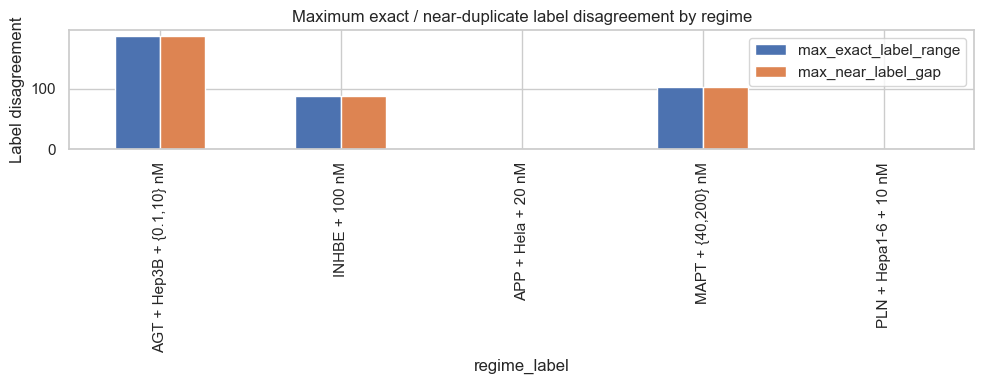

In [10]:
if not regime_audit.empty:
    plot_df = regime_audit.set_index("regime_label")[["max_exact_label_range", "max_near_label_gap"]]
    plot_df.plot(kind="bar", figsize=(10, 4))
    plt.ylabel("Label disagreement")
    plt.title("Maximum exact / near-duplicate label disagreement by regime")
    plt.tight_layout()

## How To Interpret The Results

- Large `y_true_range` for exact duplicates is the strongest signal of inconsistent labels.
- Large `label_gap` among near-duplicates suggests local instability even when the duplexes are almost the same.
- If a regime has many contradictory duplicate or near-duplicate pairs, that supports targeted cleaning or removal.
- If a regime looks hard but internally consistent, it is more likely a real biological challenge and a good CNN stress test.